In [2]:
import pandas as pd

In [3]:
import pandas as pd 

In [4]:
df=pd.read_csv("online retail.csv",encoding="utf-8")

In [5]:
df.shape

(541909, 8)

In [6]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')

In [7]:
df["Revenue"]=df["Quantity"]*df["UnitPrice"]

In [8]:
df[["Quantity","UnitPrice","Revenue"]].head(10)

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34
5,2,7.65,15.30
6,6,4.25,25.50
7,6,1.85,11.10
8,6,1.85,11.10
9,32,1.69,54.08


In [9]:
country_sales=(df.groupby("Country")["Revenue"].sum().sort_values(ascending=False))
country_sales.head(10)

Country
United Kingdom    8187806.364
Netherlands        284661.540
EIRE               263276.820
Germany            221698.210
France             197403.900
Australia          137077.270
Switzerland         56385.350
Spain               54774.580
Belgium             40910.960
Sweden              36595.910
Name: Revenue, dtype: float64

In [12]:
top_customers= (df.dropna(subset=["CustomerID"]).groupby("CustomerID")["Revenue"]
.sum().sort_values(ascending=False)
.head(10)
)


In [15]:
import matplotlib.pyplot as plt

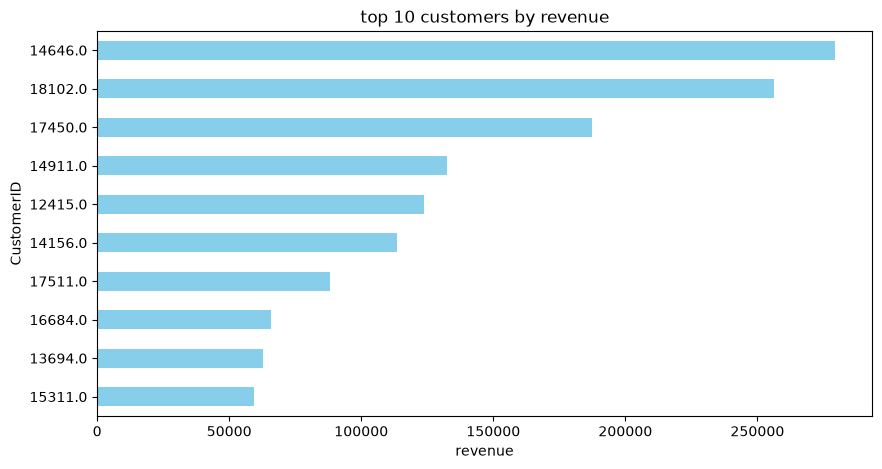

In [18]:
plt.figure(figsize=(10,5))
top_customers.sort_values().plot(kind='barh',color='skyblue')
plt.title("top 10 customers by revenue")
plt.xlabel("revenue")
plt.ylabel("CustomerID")
plt.show()

In [21]:
Customer_order=(df.groupby("CustomerID")["InvoiceNo"].nunique().reset_index())
Customer_order.columns=['CustomerID','Number of orders']
Customer_order.sort_values(by='Number of orders',ascending=False).head(10)  

,CustomerID,Number of orders
1895,14911.0,248
330,12748.0,224
4042,17841.0,169
1674,14606.0,128
568,13089.0,118
2192,15311.0,118
487,12971.0,89
1615,14527.0,86
803,13408.0,81
1703,14646.0,77


In [25]:
Customer_spending=(
    df.groupby("CustomerID")["TotalPrice"].sum().reset_index()
)
Customer_spending.columns=['CustomerID','TotalSpent']

In [26]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'TotalPrice'],
      dtype='str')